# Introduction

In this notebook, we are going to perform sanity checks on potential issues those we've noticed in the first notebook, ``01_data_acquisition.ipynb``. Also, we are going to produce 8 compass directions column and unit vector direction columns from the original polar angle `wind_direction_10m` column.

# Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from src.plotting_utils import plot_time_slice

In [2]:
raw_all_df = pd.read_csv(
    "data/processed/adelaide_hourly_weather.csv",
    parse_dates=["datetime_utc"],
    index_col="datetime_utc"
)
raw_all_df["datetime_local"] = raw_all_df.index.tz_convert("Australia/Adelaide")
raw_all_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,datetime_local,date_local,hour_local,month_local
datetime_utc,,,,,,,,,,,,,,,
2003-12-31 13:30:00+00:00,19.189999,62.846900,11.940001,17.814700,0.0,1013.6,13.551500,163.00910,0.0,0.0,14.638624,2004-01-01 00:00:00+10:30,2004-01-01,0,1
2003-12-31 14:30:00+00:00,18.390000,67.164460,12.190001,17.394241,0.0,1013.3,11.503113,159.86362,0.0,0.0,14.437140,2004-01-01 01:00:00+10:30,2004-01-01,1,1
2003-12-31 15:30:00+00:00,17.740000,71.356514,12.490001,17.008575,0.0,1012.8,10.365251,159.67677,0.0,0.0,14.335859,2004-01-01 02:00:00+10:30,2004-01-01,2,1
2003-12-31 16:30:00+00:00,17.189999,75.343920,12.790000,16.558638,0.0,1012.8,10.365251,159.67677,0.0,0.0,14.287519,2004-01-01 03:00:00+10:30,2004-01-01,3,1
2003-12-31 17:30:00+00:00,16.640000,79.822290,13.140000,16.225534,0.0,1013.1,9.693296,158.19853,0.0,0.0,14.282982,2004-01-01 04:00:00+10:30,2004-01-01,4,1


# List of Potential Issues and Additional Modifications

**Potential Sensor Associated Issues:**
* `dew_point_2m`: *"2019-December-25"*
* `precipitation`: *"2020-February-01"*
* `pressure_msl`: *"2016-September-29", "2022-May-29"*

**Modifications:**
* Wind direction: 8 compass directions and unit vector direction columns are going to be derived from the original wind direction column.



# Check Potential Sensor Associated Issues

## `dew_point_2m`
**2019-December-25**

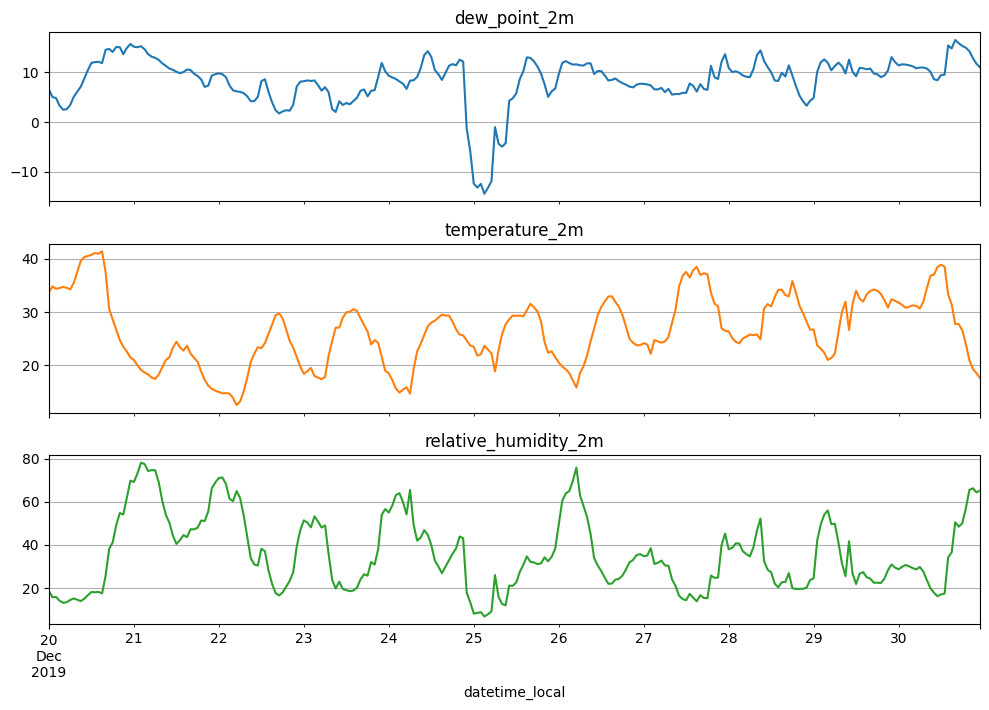

In [6]:
plot_time_slice(raw_all_df, '2019-12-20', '2019-12-30', 
                ['dew_point_2m', 'temperature_2m', 'relative_humidity_2m'], 
                datetime_type="local", subplots=True )

Dew point about *2019-December-25* is not actually unreasonable with respect to related other two variables which are `temperature_2m` and `relative_humidity_2m`. Especially `dew_point_2m` changes match with `relative_humidity_2m` changes well. For further investigation: 
 - we can check the first difference of the `dew_point_2m` column at this date (derivative with respect to time), 
 - and we can validate values with dew point calculation formula  **Magnus-Tetens equation**.

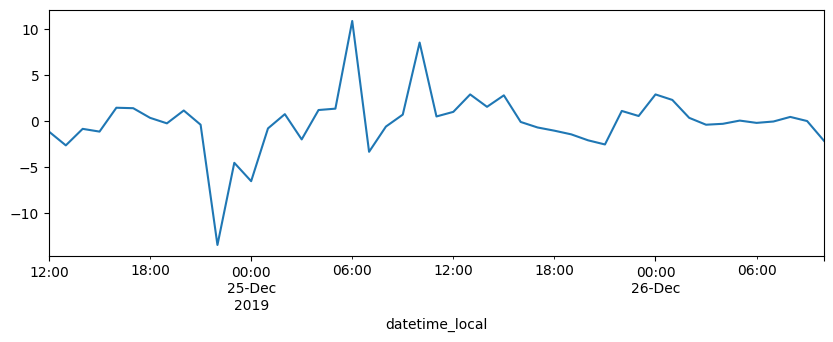

In [20]:
dew = raw_all_df.loc['2019-12-24':'2019-12-25', ['dew_point_2m', 'temperature_2m', 'relative_humidity_2m', 'datetime_local']]
dew['dew_diff'] = dew['dew_point_2m'].diff()
dew.set_index('datetime_local', inplace=True)
dew.dropna()['dew_diff'].plot(figsize=(10, 3.2))
plt.show()

Formula and information source: [Understanding Comfort Dew Point and Measuring It](https://www.codasensor.com/understanding-dew-point.html)
$$
T_d = \frac{237.3 \left( \ln\left(\frac{RH}{100}\right) + \frac{17.27\,T_c}{237.3 + T_c} \right)}
{17.27 - \ln\left(\frac{RH}{100}\right) - \frac{17.27\,T_c}{237.3 + T_c}}
$$
* **Tc**: Air temperature in °C
* **RH**: Relative humidity in %
* **Td**: Dew point temperature in °C

<Axes: xlabel='datetime_local'>

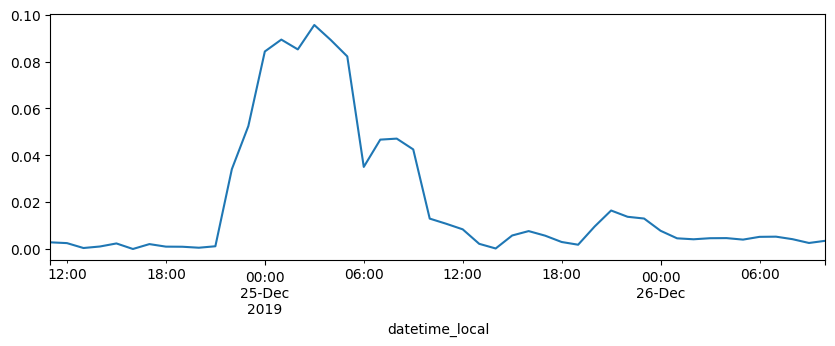

In [ ]:
# Magnus-Tetens equation
def compute_dew_point(Tc, RH): 
    RH = np.clip(RH, 1e-6, 100)  # avoid log(0)
    alpha = np.log(RH / 100.0) + (17.27 * Tc) / (237.3 + Tc)
    Td = (237.3 * alpha) / (17.27 - alpha)
    return Td

computed_dew_points = compute_dew_point(dew['temperature_2m'], dew['relative_humidity_2m'])
np.abs(dew['dew_point_2m'] - computed_dew_points).plot(figsize=(10, 3.2))

When we look at the first difference (derivative with respect to time) of the `dew_point_2m`, there several points exceeding the 10 with its absolute value. But we can see that formula values and the actual values match with maximum deviation of $<0.1\degree\text{C}$. Even most deviating part matches with possible sensor error part, we can ignore it without caping to more normal value due to original values reflect real values more.

Lastly this two web pages are in favor of not being a sensor error:
 - [Greater Adelaide in December 2019: dry and very warm](https://www.bom.gov.au/climate/current/month/sa/archive/201912.adelaide.shtml#daily)
 - [December 24 Weather in Adelaide](https://weatherspark.com/h/d/143693/2019/12/24/Historical-Weather-on-Tuesday-December-24-2019-in-Adelaide-South-Australia-Australia#Figures-Humidity)

## `precipitation`
**2020-February-01**

In [24]:
raw_all_df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'pressure_msl',
       'wind_speed_10m', 'wind_direction_10m', 'cloud_cover',
       'shortwave_radiation', 'wet_bulb_temperature_2m', 'datetime_local',
       'date_local', 'hour_local', 'month_local'],
      dtype='object')

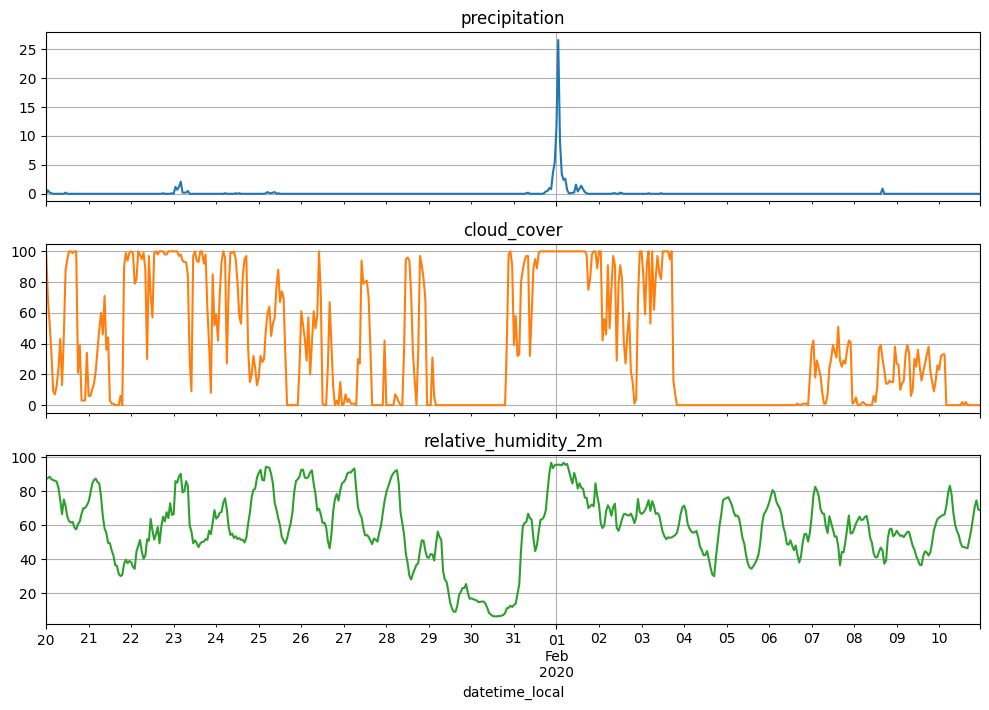

In [3]:
plot_time_slice(raw_all_df, '2020-01-20', '2020-02-10', 
                ['precipitation', 'cloud_cover', 'relative_humidity_2m'], 
                datetime_type="local", subplots=True) 

*2020-February-01* dense precipitation can be cross-validated with `cloud_cover` and `relative_humidity_2m` variable values. It seems that is not a sensor error. We keep original value.

## `pressure_msl`
**2016-September-29**

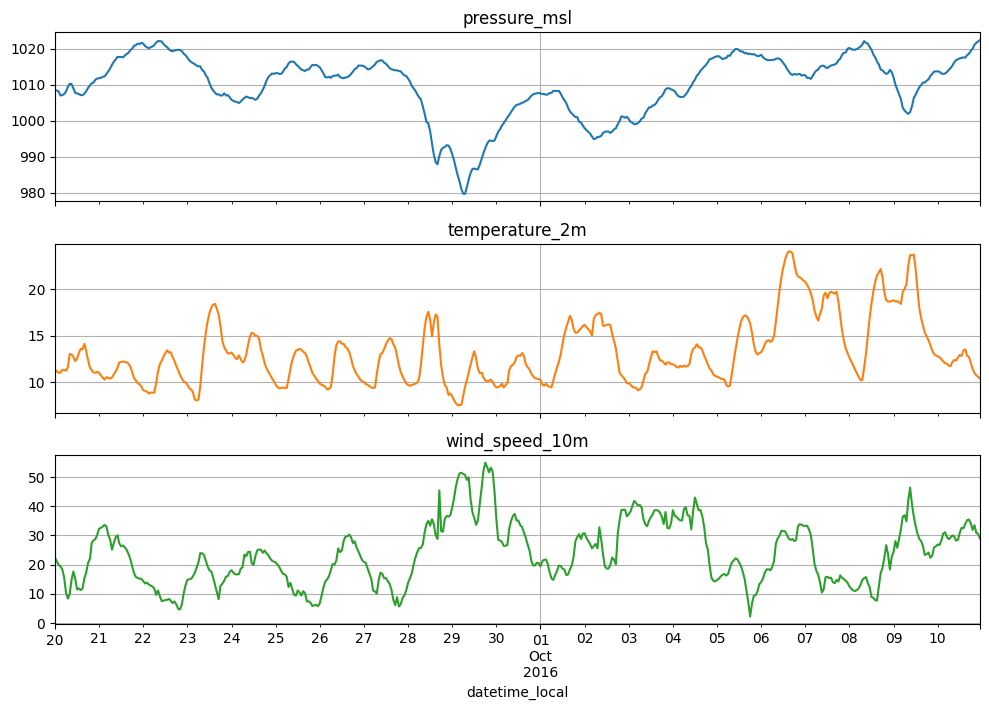

In [4]:
plot_time_slice(raw_all_df, '2016-09-20', '2016-10-10', 
                ['pressure_msl', 'temperature_2m', 'wind_speed_10m'], 
                datetime_type="local", subplots=True) 

Low pressure at *2016-09-29* can be cross-validated with low `temperature_2m` and high `wind_speed_10m` values. Change instants at three variables match. It seems that is not a sensor error. We keep original value.

**2022-May-29**

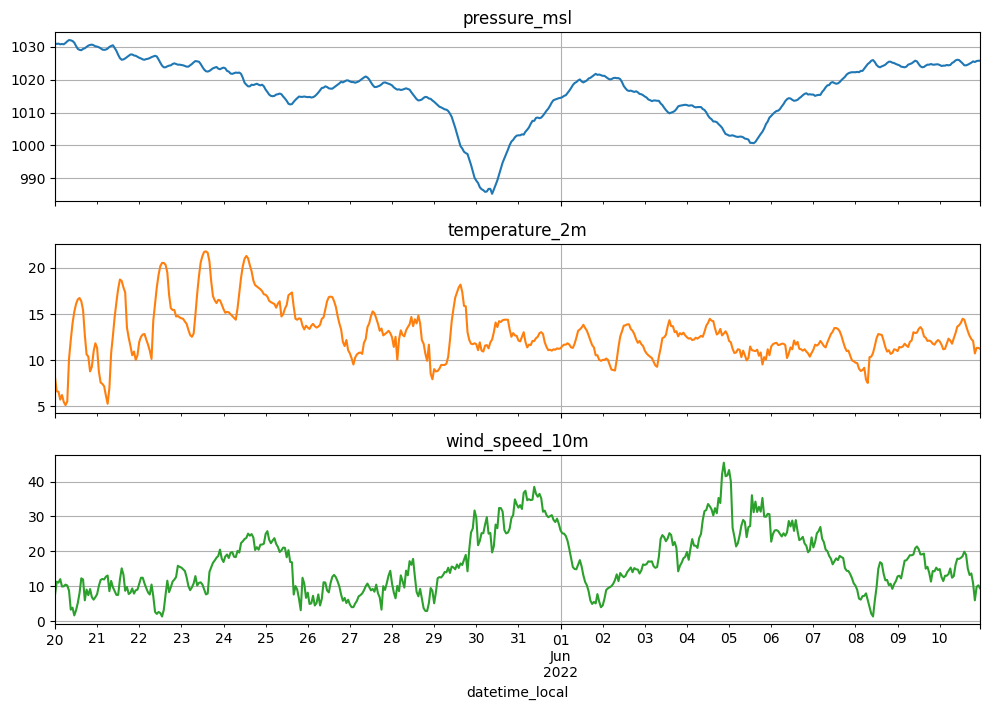

In [5]:
plot_time_slice(raw_all_df, '2022-05-20', '2022-06-10', 
                ['pressure_msl', 'temperature_2m', 'wind_speed_10m'], 
                datetime_type="local", subplots=True) 

Low pressure at *2022-05-29* also can be cross-validated as we did in previous case. We keep original value here too. 

# Modifications: Wind Direction Column Derivations


**8 Compass Directions** and **Unit Vector Direction** columns.

In [ ]:
from src.general_utils import wind_to_compass8

raw_all_df['wind_direction_compass'] = wind_to_compass8(raw_all_df['wind_direction_10m'])
raw_all_df['wind_unit_x'] = np.cos(np.deg2rad(raw_all_df['wind_direction_10m'])) 
raw_all_df['wind_unit_y'] = np.sin(np.deg2rad(raw_all_df['wind_direction_10m']))
raw_all_df[['wind_direction_10m', 'wind_direction_compass', 'wind_unit_x', 'wind_unit_y']].head()

,wind_direction_10m,wind_direction_compass,wind_unit_x,wind_unit_y
datetime_utc,,,,
2003-12-31 13:30:00+00:00,163.00910,S,-0.956351,0.292220
2003-12-31 14:30:00+00:00,159.86362,S,-0.938876,0.344256
2003-12-31 15:30:00+00:00,159.67677,S,-0.937748,0.347316
2003-12-31 16:30:00+00:00,159.67677,S,-0.937748,0.347316
2003-12-31 17:30:00+00:00,158.19853,S,-0.928476,0.371392


These columns are going to be used at analysis and modeling. 

In [36]:
raw_all_df.to_csv('data/processed/adelaide_hourly_weather_cleaned.csv', index=True, index_label="datetime_utc")

Now, data is ready for analysis and statistical studies, with file name `adelaide_hourly_weather_cleaned.csv`.